In [2]:
from textblob import TextBlob
import nltk
nltk.download('punkt')
nltk.download('stopwords') # For removing common words
nltk.download('averaged_perceptron_tagger') # For Part-of-Speech tagging (used in lemmatization)
nltk.download('wordnet') # For lemmatization
! python -m textblob.download_corpora
# Sample reviews with associated sentiment (as provided)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\obuat.ing2027\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\obuat.ing2027\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\obuat.ing2027\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\obuat.ing2027\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Finished.


[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\obuat.ing2027\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\obuat.ing2027\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\obuat.ing2027\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\obuat.ing2027\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to
[nltk_data]     C:\Users\obuat.ing2027\AppData\Roaming\nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\obuat.ing2027\AppData\Roaming\nltk_da

In [5]:
import pandas as pd
df = pd.read_csv("../datasets/amazon_review.csv")
df

,reviewText,Positive
0,This is a one of the best apps acording to a b...,1
1,This is a pretty good version of the game for ...,1
2,this is a really cool game. there are a bunch ...,1
3,"This is a silly game and can be frustrating, b...",1
4,This is a terrific game on any pad. Hrs of fun...,1
...,...,...
19995,this app is fricken stupid.it froze on the kin...,0
19996,Please add me!!!!! I need neighbors! Ginger101...,1
19997,love it! this game. is awesome. wish it had m...,1
19998,I love love love this app on my side of fashio...,1




1.   Can you perform a sentiment analysis on the collection of product reviews, classify each one as 'positive', 'negative', or 'neutral', and then generate a bar chart to visualize the distribution of these sentiments?"

2.   convert the text to lowercase, remove punctuation and numbers, filter out common stopwords, and then lemmatize the remaining words using their appropriate part-of-speech tags.
3. fter the text has been fully preprocessed and lemmatized, could you calculate the frequency of each unique word and then display a bar graph showing the top 15 most common words?
4. generate a word cloud based on the entire corpus of lemmatized review words to provide a visual summary of the most prominent terms.
5. Visualize the frequency of nouns, verbs, adjectives in this text.



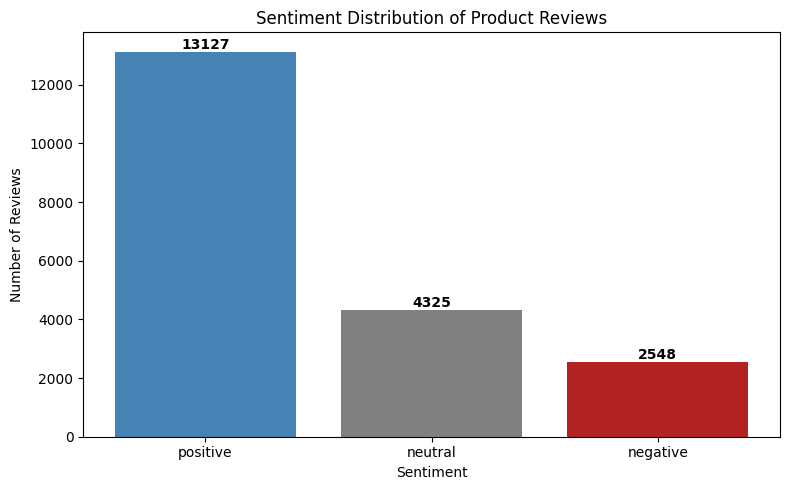

Sentiment
positive    13127
neutral      4325
negative     2548
Name: count, dtype: int64


In [7]:
import matplotlib.pyplot as plt
from textblob import TextBlob

def get_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    if polarity > 0.1:
        return 'positive'
    elif polarity < -0.1:
        return 'negative'
    else:
        return 'neutral'

df['Sentiment'] = df.iloc[:, 0].apply(get_sentiment)

sentiment_counts = df['Sentiment'].value_counts()

plt.figure(figsize=(8, 5))
colors = {'positive': 'steelblue', 'neutral': 'gray', 'negative': 'firebrick'}
bars = plt.bar(sentiment_counts.index, sentiment_counts.values,
               color=[colors.get(s, 'gray') for s in sentiment_counts.index])
plt.title("Sentiment Distribution of Product Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
for bar, count in zip(bars, sentiment_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(count), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

print(df['Sentiment'].value_counts())

In [8]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, word_tokenize

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    """Convertit les tags POS de NLTK en format WordNet"""
    from nltk.corpus import wordnet
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def preprocess(text):
    # Lowercase
    text = str(text).lower()
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    # POS tagging + Lemmatization
    pos_tags = pos_tag(tokens)
    tokens = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in pos_tags]
    return tokens

df['Tokens'] = df.iloc[:, 0].apply(preprocess)
print(df['Tokens'].head())

0    [one, best, apps, acording, bunch, people, agr...
1    [pretty, good, version, game, free, lot, diffe...
2    [really, cool, game, bunch, level, find, golde...
3    [silly, game, frustrate, lot, fun, definitely,...
4    [terrific, game, pad, hr, fun, grandkids, love...
Name: Tokens, dtype: object


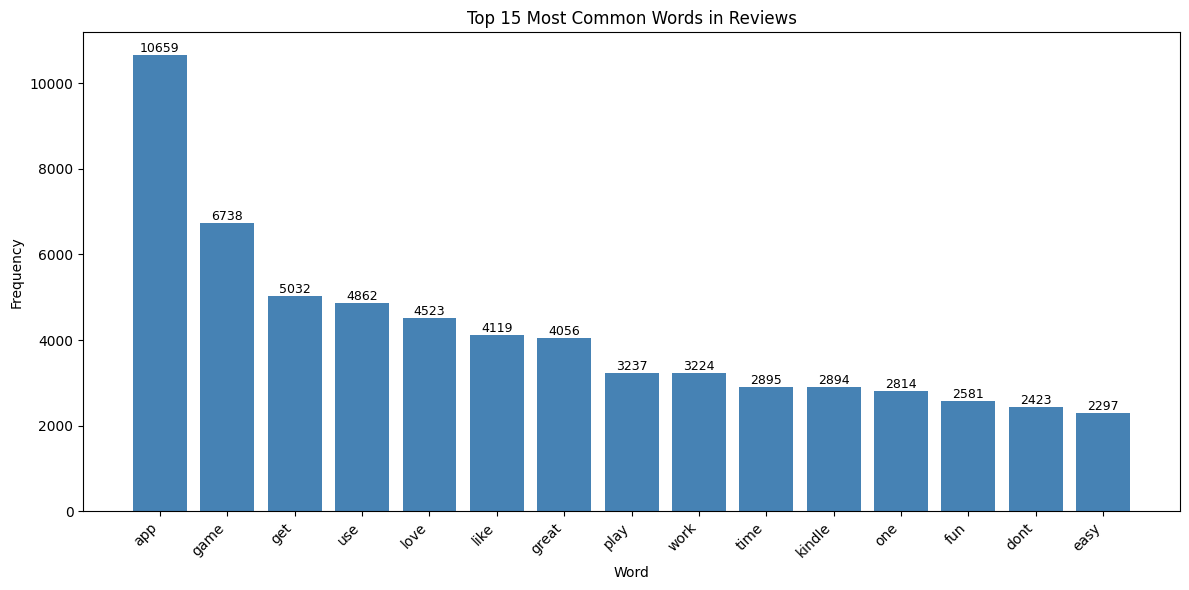

In [9]:
from collections import Counter

all_words = [word for tokens in df['Tokens'] for word in tokens]
word_freq = Counter(all_words)
top_15 = word_freq.most_common(15)

words, counts = zip(*top_15)

plt.figure(figsize=(12, 6))
bars = plt.bar(words, counts, color='steelblue')
plt.title("Top 15 Most Common Words in Reviews")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha='right')
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(count), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

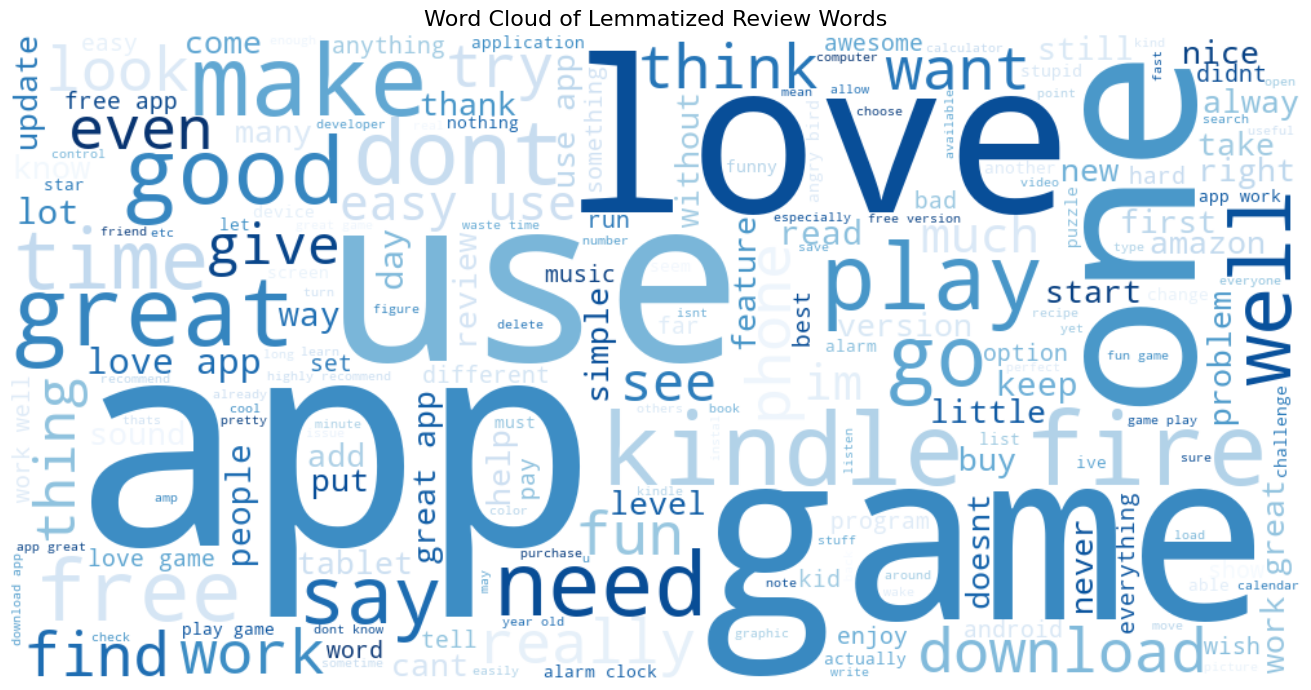

In [10]:
from wordcloud import WordCloud

# Installe si besoin : pip install wordcloud
text_for_cloud = ' '.join(all_words)

wc = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='Blues',
    max_words=200
).generate(text_for_cloud)

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Lemmatized Review Words", fontsize=16)
plt.tight_layout()
plt.show()

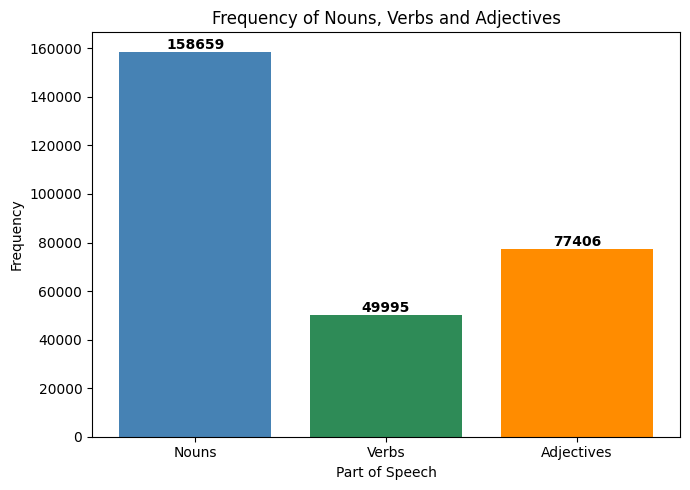

In [ ]:
from nltk import pos_tag

all_tokens_flat = [word for tokens in df['Tokens'] for word in tokens]
pos_tags_all = pos_tag(all_tokens_flat)

pos_counts = {'Nouns': 0, 'Verbs': 0, 'Adjectives': 0}
for word, tag in pos_tags_all:
    if tag.startswith('NN'):
        pos_counts['Nouns'] += 1
    elif tag.startswith('VB'):
        pos_counts['Verbs'] += 1
    elif tag.startswith('JJ'):
        pos_counts['Adjectives'] += 1

plt.figure(figsize=(7, 5))
bars = plt.bar(pos_counts.keys(), pos_counts.values(),
               color=['steelblue', 'seagreen', 'darkorange'])
plt.title("Frequency of Nouns, Verbs and Adjectives")
plt.xlabel("Part of Speech")
plt.ylabel("Frequency")
for bar, count in zip(bars, pos_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()